# Mall Customer Segmentation — Part 2: Supervised Classifier

**Goal:** Train and tune multiple classifiers to predict which customer segment a brand new customer belongs to, using cluster labels from Part 1 as the target.

**Why supervised after unsupervised?**
Clustering can only label data it has already seen. A trained classifier lets us predict the segment for *new* customers instantly — without re-running clustering.

**Models compared:**
| Model | Type | Key strength |
|---|---|---|
| Logistic Regression | Linear baseline | Fast, interpretable |
| Random Forest | Ensemble (bagging) | Robust, handles noise |
| XGBoost | Ensemble (boosting) | Best on tabular data, corrects errors sequentially |
| SVM | Margin-based | Excellent on small datasets with clear boundaries |

**All models tuned with GridSearchCV + 5-fold stratified cross-validation.**

**Dataset:** `clustered_customers.csv` exported from Part 1
**Features:** Age, Gender, Annual Income (k$), Spending Score (1-100)
**Target:** `Cluster_Label`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

from google.colab import drive

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

## 2. Load Data

In [2]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ML_Projects/MallCustomerSegmentation/clustered_customers.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nCluster distribution:")
print(df['Cluster_Label'].value_counts().sort_index())
df.head()

Mounted at /content/drive
Dataset shape: (200, 5)

Cluster distribution:
Cluster_Label
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


,Age,Gender,Annual Income (k$),Spending Score (1-100),Cluster_Label
0,19,Male,15,39,4
1,21,Male,15,81,2
2,20,Female,16,6,4
3,23,Female,16,77,2
4,31,Female,17,40,4


## 3. EDA — Labelled Dataset

Verify class balance and confirm features separate cleanly across clusters before modelling.

In [3]:
print("=== Null Values ===")
print(df.isnull().sum())
print("\n=== Data Types ===")
df.info()

=== Null Values ===
Age                       0
Gender                    0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster_Label             0
dtype: int64

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
 4   Cluster_Label           200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


/tmp/ipykernel_2343/3381121207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_Label', y=col, palette='viridis', ax=ax)
/tmp/ipykernel_2343/3381121207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_Label', y=col, palette='viridis', ax=ax)
/tmp/ipykernel_2343/3381121207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_Label', y=col, palette='viridis', ax=ax)


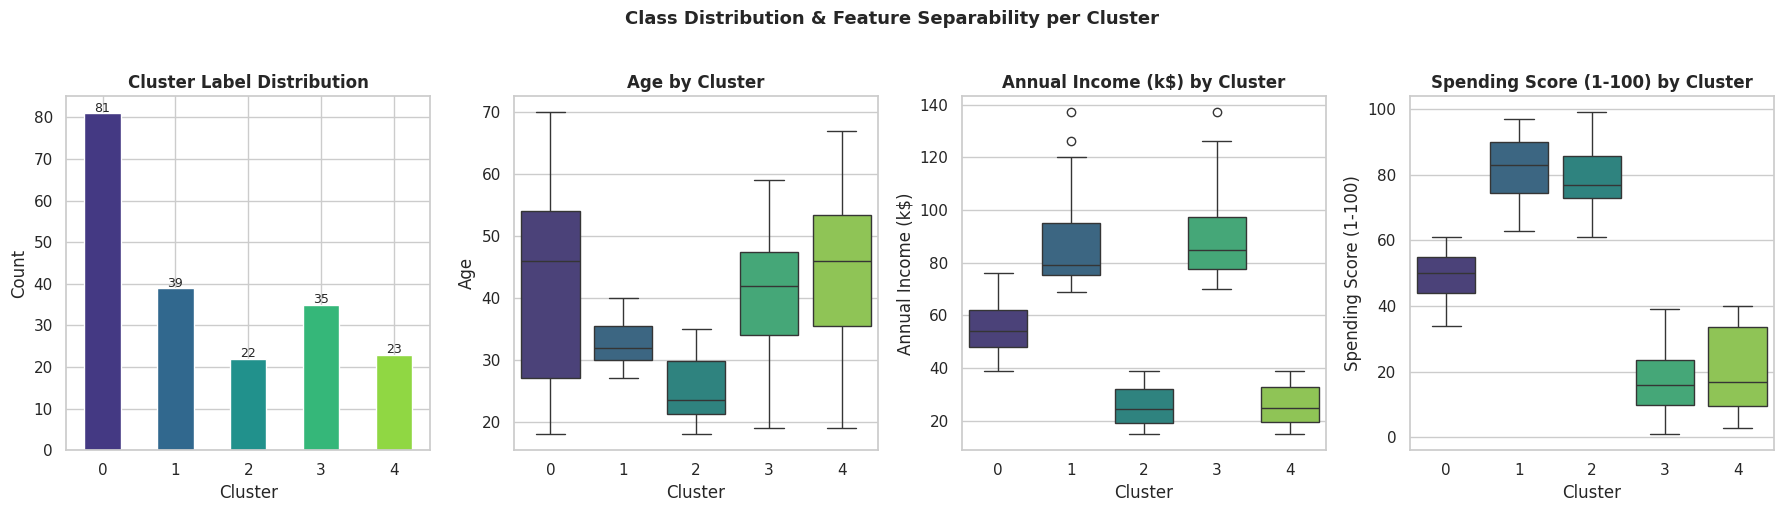

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Class distribution
n_clusters = df['Cluster_Label'].nunique()
palette = sns.color_palette('viridis', n_clusters)
ax = axes[0]
df['Cluster_Label'].value_counts().sort_index().plot(kind='bar', color=palette, ax=ax)
ax.set_title('Cluster Label Distribution', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.3, int(p.get_height()), ha='center', fontsize=9)

# Feature distributions per cluster
for ax, col in zip(axes[1:], ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(data=df, x='Cluster_Label', y=col, palette='viridis', ax=ax)
    ax.set_title(f'{col} by Cluster', fontweight='bold')
    ax.set_xlabel('Cluster')

plt.suptitle('Class Distribution & Feature Separability per Cluster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

All 4 features are used — including **Gender**, which was excluded from clustering (it reduced Silhouette Score) but is useful here because classifiers can learn non-linear interactions between Gender and other features.

- **Gender** → Label Encoded (Female=0, Male=1)
- **All features** → StandardScaler (required for Logistic Regression and SVM; consistent for all models)

In [5]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
print(f"Gender encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

feature_cols = ['Age', 'Gender_encoded', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_cols].copy()
y = df['Cluster_Label'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print(f"\nFeatures : {feature_cols}")
print(f"Target   : Cluster_Label — {sorted(y.unique())}")

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Features : ['Age', 'Gender_encoded', 'Annual Income (k$)', 'Spending Score (1-100)']
Target   : Cluster_Label — [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 5. Train / Test Split

**Stratified split** preserves class proportions in both sets — important when clusters have unequal sizes.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index().to_dict()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index().to_dict()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train : 160 rows
Test  : 40 rows

Train class distribution:
{0: 65, 1: 31, 2: 18, 3: 28, 4: 18}

Test class distribution:
{0: 16, 1: 8, 2: 4, 3: 7, 4: 5}


## 6. Logistic Regression + GridSearchCV

**How it works:** Learns a linear decision boundary between classes using softmax for multi-class.

**Hyperparameters tuned:**
- `C` — regularisation strength (smaller = more regularisation, prevents overfitting)
- `solver` — optimisation algorithm; `lbfgs` and `saga` work well for multi-class

In [7]:
lr_param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'saga'],
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

best_lr     = lr_grid.best_estimator_
lr_test_acc = accuracy_score(y_test, best_lr.predict(X_test))
lr_cv_mean  = lr_grid.best_score_

print(f"Logistic Regression — Best Params : {lr_grid.best_params_}")
print(f"  CV Accuracy (train) : {lr_cv_mean:.4f}")
print(f"  Test Accuracy       : {lr_test_acc:.4f}")

Logistic Regression — Best Params : {'C': 100, 'solver': 'lbfgs'}
  CV Accuracy (train) : 0.9625
  Test Accuracy       : 0.9750


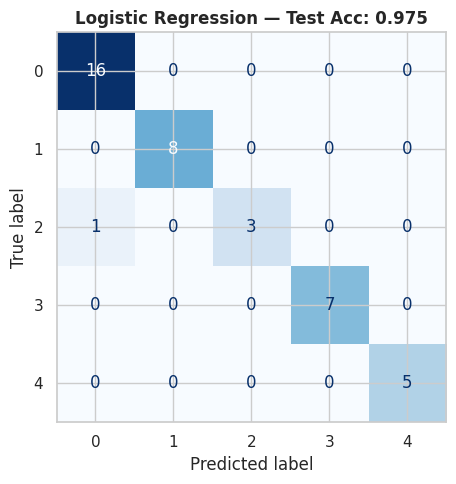

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_lr.predict(X_test), ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Logistic Regression — Test Acc: {lr_test_acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Random Forest + GridSearchCV

**How it works:** Builds many decision trees on random data/feature subsets (bagging), then majority-votes predictions. Reduces variance and overfitting vs a single tree.

**Hyperparameters tuned:**
- `n_estimators` — number of trees (more = more stable but slower)
- `max_depth` — max tree depth (controls overfitting)
- `min_samples_split` — minimum samples to split a node

In [9]:
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10],
    'min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

best_rf     = rf_grid.best_estimator_
rf_test_acc = accuracy_score(y_test, best_rf.predict(X_test))
rf_cv_mean  = rf_grid.best_score_

print(f"Random Forest — Best Params : {rf_grid.best_params_}")
print(f"  CV Accuracy (train) : {rf_cv_mean:.4f}")
print(f"  Test Accuracy       : {rf_test_acc:.4f}")

Random Forest — Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV Accuracy (train) : 0.9688
  Test Accuracy       : 0.9750


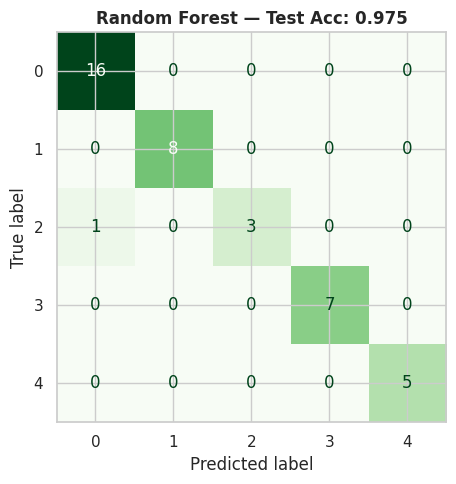

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_rf.predict(X_test), ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Random Forest — Test Acc: {rf_test_acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. XGBoost + GridSearchCV

**How it works:** Builds trees *sequentially* — each new tree focuses on correcting the mistakes of the previous one (boosting). Adds regularisation to prevent overfitting. Generally the strongest performer on structured/tabular data.

**Hyperparameters tuned:**
- `n_estimators` — number of boosting rounds
- `learning_rate` — how much each tree contributes (lower = more conservative, needs more trees)
- `max_depth` — tree complexity
- `subsample` — fraction of data used per tree (reduces overfitting)

In [11]:
xgb_param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth'    : [3, 5, 7],
    'subsample'    : [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)

best_xgb     = xgb_grid.best_estimator_
xgb_test_acc = accuracy_score(y_test, best_xgb.predict(X_test))
xgb_cv_mean  = xgb_grid.best_score_

print(f"XGBoost — Best Params : {xgb_grid.best_params_}")
print(f"  CV Accuracy (train) : {xgb_cv_mean:.4f}")
print(f"  Test Accuracy       : {xgb_test_acc:.4f}")

XGBoost — Best Params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  CV Accuracy (train) : 0.9437
  Test Accuracy       : 0.9750


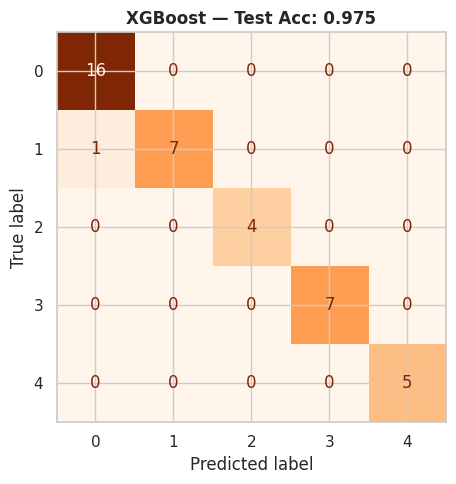

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_xgb.predict(X_test), ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'XGBoost — Test Acc: {xgb_test_acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. SVM + GridSearchCV

**How it works:** Finds the hyperplane that maximises the *margin* between classes. Uses the kernel trick to handle non-linear boundaries by projecting data into higher dimensions.

**Why great for this dataset:** Small dataset (200 rows), well-scaled features, clear cluster boundaries — ideal SVM conditions.

**Hyperparameters tuned:**
- `C` — margin strictness (high C = smaller margin, fits training data more closely)
- `kernel` — `linear` for straight boundaries, `rbf` for curved boundaries
- `gamma` — how far the influence of a single training point reaches (`rbf` only)

In [13]:
svm_param_grid = {
    'C'     : [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma' : ['scale', 'auto'],
}

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_train, y_train)

best_svm     = svm_grid.best_estimator_
svm_test_acc = accuracy_score(y_test, best_svm.predict(X_test))
svm_cv_mean  = svm_grid.best_score_

print(f"SVM — Best Params : {svm_grid.best_params_}")
print(f"  CV Accuracy (train) : {svm_cv_mean:.4f}")
print(f"  Test Accuracy       : {svm_test_acc:.4f}")

SVM — Best Params : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
  CV Accuracy (train) : 0.9750
  Test Accuracy       : 0.9750


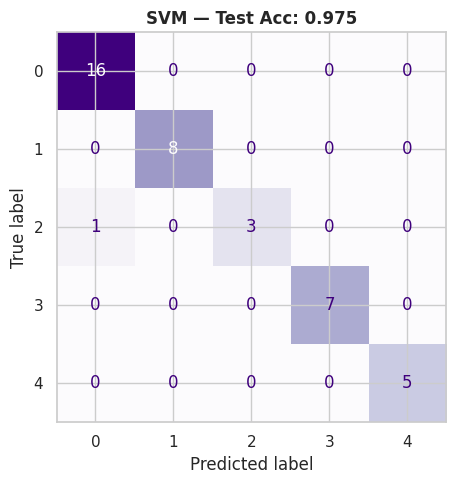

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_svm.predict(X_test), ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'SVM — Test Acc: {svm_test_acc:.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Model Comparison — Pick the Best Classifier

We rank by **CV accuracy** (most reliable — tested on 5 different folds) rather than test accuracy alone, which can vary by luck of the split.

In [15]:
results = pd.DataFrame({
    'Model'        : ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Best Params'  : [
        str(lr_grid.best_params_),
        str(rf_grid.best_params_),
        str(xgb_grid.best_params_),
        str(svm_grid.best_params_),
    ],
    'CV Accuracy'  : [lr_cv_mean,  rf_cv_mean,  xgb_cv_mean,  svm_cv_mean],
    'Test Accuracy': [lr_test_acc, rf_test_acc, xgb_test_acc, svm_test_acc],
}).set_index('Model')

display(results.drop(columns='Best Params').round(4))

BEST_MODEL_NAME = results['CV Accuracy'].idxmax()
BEST_MODEL      = {'Logistic Regression': best_lr,
                   'Random Forest'      : best_rf,
                   'XGBoost'            : best_xgb,
                   'SVM'                : best_svm}[BEST_MODEL_NAME]

print(f"\n✅ Best classifier (highest CV accuracy): {BEST_MODEL_NAME}")
print(f"   CV Accuracy  : {results.loc[BEST_MODEL_NAME, 'CV Accuracy']:.4f}")
print(f"   Test Accuracy: {results.loc[BEST_MODEL_NAME, 'Test Accuracy']:.4f}")

,CV Accuracy,Test Accuracy
Model,,
Logistic Regression,0.9625,0.975
Random Forest,0.9688,0.975
XGBoost,0.9438,0.975
SVM,0.9750,0.975



✅ Best classifier (highest CV accuracy): SVM
   CV Accuracy  : 0.9750
   Test Accuracy: 0.9750


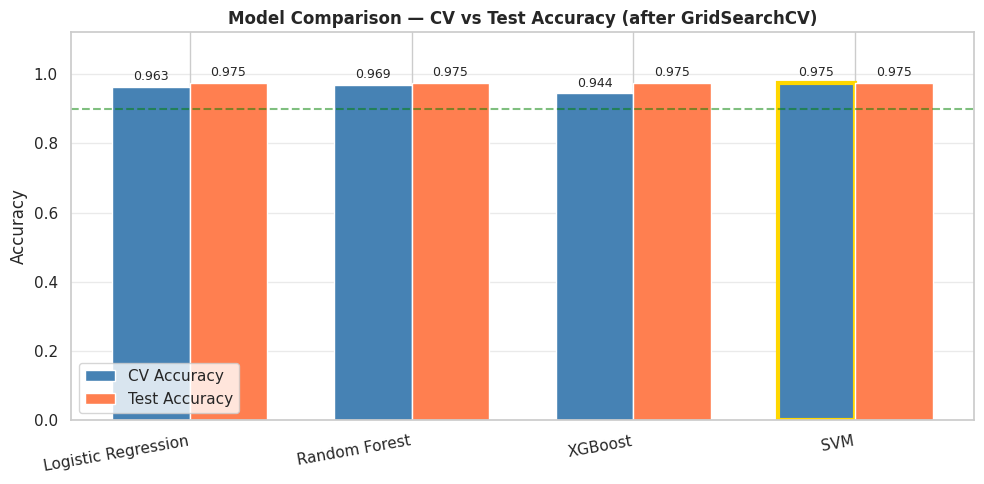

In [16]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(4)
width  = 0.35
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']
cv_scores   = [lr_cv_mean,  rf_cv_mean,  xgb_cv_mean,  svm_cv_mean]
test_scores = [lr_test_acc, rf_test_acc, xgb_test_acc, svm_test_acc]

bars1 = ax.bar(x - width/2, cv_scores,   width, label='CV Accuracy',   color='steelblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison — CV vs Test Accuracy (after GridSearchCV)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='0.9 threshold')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Highlight winner
winner_idx = models.index(BEST_MODEL_NAME)
ax.patches[winner_idx].set_edgecolor('gold')
ax.patches[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

## 11. Classification Report — Best Model

=== SVM — Full Classification Report ===

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      1.00      1.00         8
           2       1.00      0.75      0.86         4
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         5

    accuracy                           0.97        40
   macro avg       0.99      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



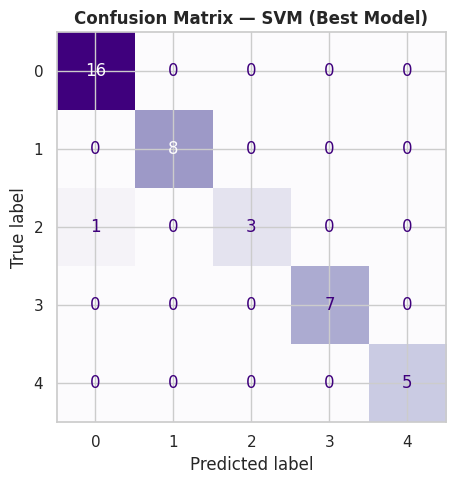

In [17]:
print(f"=== {BEST_MODEL_NAME} — Full Classification Report ===\n")
print(classification_report(y_test, BEST_MODEL.predict(X_test)))

fig, ax = plt.subplots(figsize=(7, 5))
cmap_map = {
    'Logistic Regression': 'Blues',
    'Random Forest'      : 'Greens',
    'XGBoost'            : 'Oranges',
    'SVM'                : 'Purples'
}
ConfusionMatrixDisplay.from_predictions(
    y_test, BEST_MODEL.predict(X_test),
    ax=ax, colorbar=False,
    cmap=cmap_map.get(BEST_MODEL_NAME, 'Blues')
)
ax.set_title(f'Confusion Matrix — {BEST_MODEL_NAME} (Best Model)', fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Feature Importance

Shows which features matter most for predicting customer segments.
Random Forest and XGBoost give direct importance scores; for Logistic Regression and SVM we show coefficient magnitudes.

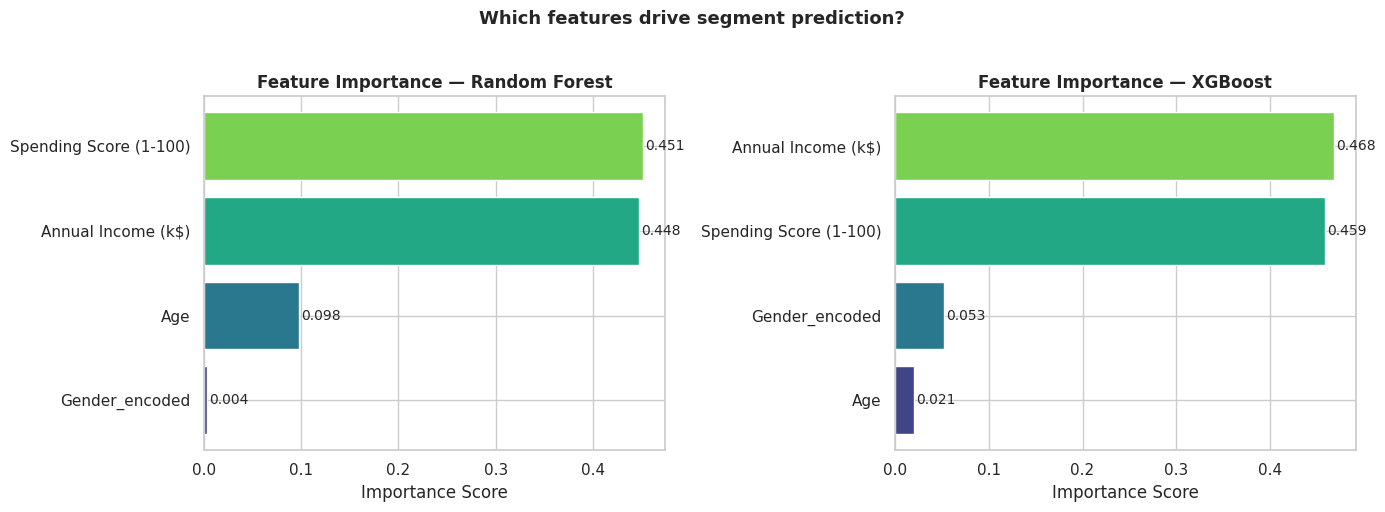

Key insight: Annual Income and Spending Score should dominate — consistent with Part 1 clustering.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest importance
rf_imp = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()
axes[0].barh(rf_imp.index, rf_imp.values, color=sns.color_palette('viridis', len(rf_imp)))
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(rf_imp.values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

# XGBoost importance
xgb_imp = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values()
axes[1].barh(xgb_imp.index, xgb_imp.values, color=sns.color_palette('viridis', len(xgb_imp)))
axes[1].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(xgb_imp.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Which features drive segment prediction?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: Annual Income and Spending Score should dominate — consistent with Part 1 clustering.")

## 13. Predict Segment for New Customers

Practical payoff — given a new customer's profile, predict their segment without re-running clustering.
Update `segment_names` to match the cluster profiles from your Part 1 output.

In [19]:
# Update these labels to match your Part 1 cluster profiles
segment_names = {
    0: 'Cautious Shoppers      (Low Income,  Low Spending)',
    1: 'Impulsive/Aspirational (Low Income,  High Spending)',
    2: 'Average Customers      (Mid Income,  Mid Spending)',
    3: 'Wealthy but Frugal     (High Income, Low Spending)',
    4: 'VIP Targets            (High Income, High Spending)',
}

def predict_segment(age, gender, annual_income, spending_score, model=BEST_MODEL):
    """Predict the cluster segment for a new customer."""
    gender_enc = 0 if gender.lower() == 'female' else 1
    raw    = pd.DataFrame([[age, gender_enc, annual_income, spending_score]], columns=feature_cols)
    scaled = pd.DataFrame(scaler.transform(raw), columns=feature_cols)
    label  = model.predict(scaled)[0]
    conf   = model.predict_proba(scaled)[0].max() * 100
    return label, conf, segment_names.get(label, f'Cluster {label}')

# Example new customers
new_customers = [
    {'age': 25, 'gender': 'Female', 'income': 15,  'spending': 81},
    {'age': 45, 'gender': 'Male',   'income': 120, 'spending': 20},
    {'age': 32, 'gender': 'Female', 'income': 85,  'spending': 78},
    {'age': 55, 'gender': 'Male',   'income': 55,  'spending': 50},
    {'age': 28, 'gender': 'Male',   'income': 30,  'spending': 72},
]

print(f"Predictions using: {BEST_MODEL_NAME}\n")
print(f"{'Age':>4} | {'Gender':>7} | {'Income':>8} | {'Spending':>9} | {'Cluster':>7} | {'Conf':>6} | Segment")
print("─" * 95)
for c in new_customers:
    lbl, conf, name = predict_segment(c['age'], c['gender'], c['income'], c['spending'])
    print(f"{c['age']:>4} | {c['gender']:>7} | {c['income']:>8} | {c['spending']:>9} | {lbl:>7} | {conf:>5.1f}% | {name}")

Predictions using: SVM

 Age |  Gender |   Income |  Spending | Cluster |   Conf | Segment
───────────────────────────────────────────────────────────────────────────────────────────────
  25 |  Female |       15 |        81 |       2 |  93.1% | Average Customers      (Mid Income,  Mid Spending)
  45 |    Male |      120 |        20 |       3 |  98.4% | Wealthy but Frugal     (High Income, Low Spending)
  32 |  Female |       85 |        78 |       1 |  91.7% | Impulsive/Aspirational (Low Income,  High Spending)
  55 |    Male |       55 |        50 |       0 |  95.5% | Cautious Shoppers      (Low Income,  Low Spending)
  28 |    Male |       30 |        72 |       2 |  67.6% | Average Customers      (Mid Income,  Mid Spending)


## 14. Summary

### What I did in Part 2
1. **Loaded** labelled dataset from Part 1
2. **EDA** — confirmed class balance and feature separability per cluster
3. **Preprocessing** — encoded Gender, scaled all 4 features
4. **Stratified train/test split** — preserved class proportions
5. **Trained 4 models** — Logistic Regression, Random Forest, XGBoost, SVM
6. **GridSearchCV** on all 4 models — systematic hyperparameter tuning via 5-fold CV
7. **Compared** CV accuracy + test accuracy → auto-selected best model
8. **Feature importance** — confirmed Income & Spending Score dominate
9. **Inference function** — `predict_segment()` ready for new customer scoring

### Model characteristics recap
| Model | Strength | Limitation |
|---|---|---|
| Logistic Regression | Fast, interpretable, good baseline | Linear boundaries only |
| Random Forest | Robust to noise, low variance | Can overfit without tuning |
| XGBoost | Best on tabular data, sequential error correction | More hyperparameters |
| SVM | Excellent on small datasets, maximises margins | Slower, less interpretable |

### Why CV accuracy > test accuracy for model selection
Test accuracy depends on one random split — it can be lucky or unlucky.
CV accuracy averages over 5 different splits, giving a much more reliable estimate of real-world performance.

### Key takeaways
- **Annual Income** and **Spending Score** are the dominant predictors — consistent with Part 1
- **Age** adds moderate signal; **Gender** contributes least
- High CV accuracy with low variance = model generalises well

### Potential next steps
- **Streamlit app** — deploy `predict_segment()` so non-technical users can input customer data and get predictions instantly
- **Retrain periodically** — as new customer data arrives, re-run clustering and retrain the classifier to keep segments current